## Agent launch pipeline

### Imports

In [1]:
from langgraph.graph import StateGraph, END

import os
import sys
import getpass

from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langchain_community.vectorstores import Chroma

sys.path.append(os.path.abspath(".."))
from agents_core.agents.primary_agent import PrimaryAgent, route_primary_agent
from agents_core.agents.rag_agent import RAGAgent, route_rag_agent
from agents_core import prompts
from agents_core.state import State
from agents_core.utils import create_agent_entry_node, leave_agent

from services.embedder_model_manager import EmbedderModelManager

/home/nikita/proga/TTRPG-Authentic-Personal-Assistant-TAPA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preparation

In [ ]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

os.environ["OPENROUTER_API_KEY"] = "..."
# _set_env("OPENROUTER_API_KEY")

os.environ["OPENAI_API_KEY"] = os.environ["OPENROUTER_API_KEY"]
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

os.environ["LANGCHAIN_API_KEY"] = "..."
# _set_env("LANGCHAIN_API_KEY")

os.environ["LANGCHAIN_PROJECT"] = "TTRPG-Authentic-Personal-Assistant-TAPA"

In [3]:
# TODO: make choosable book in future

book_name = "pf2e"

In [4]:
# Defining llm

# llm = ChatOpenAI(
#     model_name="qwen/qwen3-coder",
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.7,
#     max_tokens=2048,
#     model_kwargs={
#         "top_p": 0.8,
#     },
# )

llm = ChatOpenAI(
    model="qwen2.5:7b-instruct",
    api_key="",
    base_url="http://localhost:11434/v1",
    temperature=0.7,
    max_tokens=1024,
    model_kwargs={
        "top_p": 0.8,
    },
)

# llm = ChatOpenAI(model="nvidia/nemotron-3-nano-30b-a3b:free")

/home/nikita/proga/TTRPG-Authentic-Personal-Assistant-TAPA/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3641: UserWarning: Parameters {'top_p'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [5]:
# Defining embedder
embedder = EmbedderModelManager()
embedder.load_model()

#Getting vetror database
vector_db = Chroma(
    collection_name="books_collection",
    embedding_function=embedder,
    persist_directory="../data/vector_db",
)

Loading model: intfloat/e5-large-v2


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 615.95it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_489344/3727684530.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_db = Chroma(


In [6]:
# Defining agents and binding tools

primary_agent = PrimaryAgent(prompts.primary_agent_prompt.partial(book_name=book_name), llm)
rag_agent = RAGAgent(prompts.rag_agent_prompt.partial(book_name=book_name), llm, vector_db)

In [7]:
# Definig graph

graph_builder = StateGraph(State)

graph_builder.add_node("primary_agent", primary_agent)
graph_builder.add_node("rag_agent", rag_agent)

graph_builder.add_node("leave_agent", leave_agent)
graph_builder.add_edge("leave_agent", "primary_agent")

graph_builder.add_node("enter_rag_agent", create_agent_entry_node("rag_agent"))
graph_builder.add_edge("enter_rag_agent", "rag_agent")

graph_builder.add_node("rag_tools", ToolNode(rag_agent.tools))
graph_builder.add_edge("rag_tools", "rag_agent")

graph_builder.add_conditional_edges(
    "primary_agent",
    route_primary_agent,
    {
        "enter_rag_agent": "enter_rag_agent",
        END: END
    }
)

graph_builder.add_conditional_edges(
    "rag_agent",
    route_rag_agent,
    {
        "rag_tools": "rag_tools",
        "leave_agent": "leave_agent"
    }
)

graph_builder.set_entry_point("primary_agent")

In [8]:
graph = graph_builder.compile()

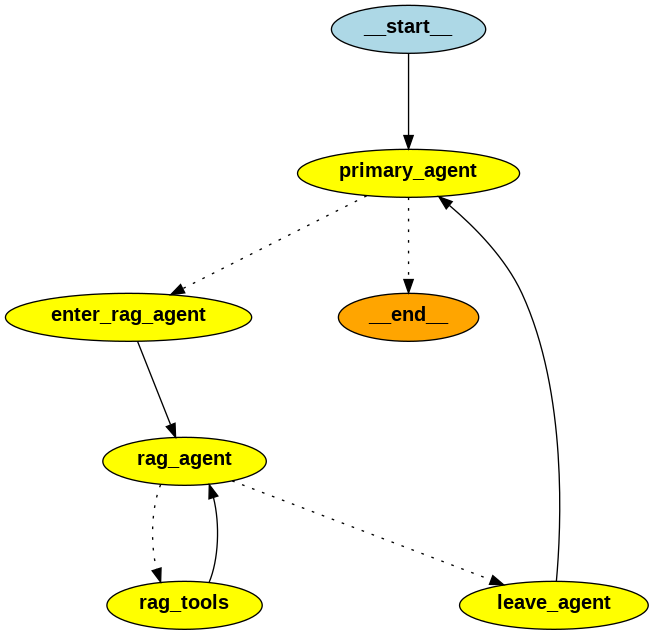

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_png()))
except Exception as e:
    print(e)

### Testing

In [10]:
def print_event(event: dict, _printed: set, max_length=1500):
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            current_state = event.get("agents_stack")
            if current_state:
                print("Currently in: ", current_state[-1])
            _printed.add(message.id)

In [11]:
events = graph.stream(
    {
        "messages": "How Oracle class works?",
        "agents_stack": "primary_agent"
    },
    stream_mode="values"
)

for event in events:
    print_event(event, set())

================================ Human Message =================================

How Oracle class works?
Currently in:  primary_agent
================================== Ai Message ==================================

To provide you with the most accurate information about the Oracle class in Pathfinder 2e, I will use the RAG tool to fetch the relevant details.
Tool Calls:
  MoveToRagAgent (call_lhmoapck)
 Call ID: call_lhmoapck
  Args:
    query: Oracle class in Pathfinder 2e
Currently in:  primary_agent
================================= Tool Message =================================


                    The agent is now the rag_agent. Reflect on the above conversation and begin your task.
                    Do not provide any additional information and complete the task as you were designed to make it. 
                    
Currently in:  rag_agent
================================== Ai Message ==================================
Tool Calls:
  search_relevant_book_data (call_in2u9ck5)